# PRZ Scaling Fit

Reproduces the `PRZ ~ 2^{0.70N}` claim (Sec VI D, Appendix D3).

For each N in [10, 12, 14, 16, 18, 20], runs ExactSimulator on 100 brickwork
L=5 circuits, computes exact-state participation ratio (PRZ), then fits
PRZ ~ C * 2^{alpha*N} with 4000-resample bootstrap CIs.

Stored in `tests/results/prz_scaling_fit.npz`.

**This notebook must be re-run to reproduce the alpha=0.70 claim.
The stored N-scaling data (nscaling_fixed_k.npz) contains only truncated-state
PR, which saturates below PRZ and cannot reproduce this fit.**


In [1]:
from pathlib import Path
import sys, json
import numpy as np
from scipy.optimize import curve_fit

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for c in (start, *start.parents):
        if (c / 'src').is_dir() and (c / 'requirements.txt').exists():
            return c
    raise RuntimeError('Repo root not found')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / 'tests' / 'results'
FIG_DIR  = REPO_ROOT / 'tests' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

from src.simulation.exact_simulator import ExactSimulator
from src.experimentation.runner import make_brickwork
from src.visualization.style import mplstyle
import matplotlib.pyplot as plt
mplstyle()

print('Imports OK.')

Imports OK.


In [6]:
# ── Configuration ──────────────────────────────────────────────────────────
N_VALUES   = [10, 12, 14, 16, 18, 20]
N_TRIALS   = 100
SEED_BASE  = 20260520
N_BOOT     = 4000
FORCE_RERUN = True

NPZ_PATH  = DATA_DIR / 'prz_scaling_fit.npz'
META_PATH = DATA_DIR / 'prz_scaling_fit_meta.json'

EXPECTED_META = {
    'N_values': N_VALUES, 'n_trials': N_TRIALS,
    'seed_base': SEED_BASE, 'circuit': 'brickwork_L5',
}

def compute_prz(sv):
    'Exact-state participation ratio: 1 / sum(|psi|^4)'
    p = np.abs(sv) ** 2
    return float(1.0 / np.sum(p ** 2))

print(f'N_VALUES={N_VALUES}, N_TRIALS={N_TRIALS}, SEED_BASE={SEED_BASE}')

N_VALUES=[10, 12, 14, 16, 18, 20], N_TRIALS=100, SEED_BASE=20260520


In [7]:
# ── Run or load ────────────────────────────────────────────────────────────
if NPZ_PATH.exists() and META_PATH.exists() and not FORCE_RERUN:
    stored_meta = json.loads(META_PATH.read_text())
    if stored_meta == EXPECTED_META:
        data = np.load(NPZ_PATH)
        prz_all = data['prz_all']   # shape (n_trials, len(N_VALUES))
        print('Loaded from cache.')
    else:
        FORCE_RERUN = True
        print('Cache meta mismatch, re-running.')

if FORCE_RERUN or not NPZ_PATH.exists():
    prz_all = np.full((N_TRIALS, len(N_VALUES)), np.nan)
    for ni, N in enumerate(N_VALUES):
        exact_sim = ExactSimulator(N, verbose=False)
        for t in range(N_TRIALS):
            seed = SEED_BASE * 10**6 + ni * 1000 + t
            rng  = np.random.default_rng(seed)
            circuit = make_brickwork(N, depth=5, rng=rng)
            sv = exact_sim.simulate(circuit)
            prz_all[t, ni] = compute_prz(sv)
        gm = float(np.exp(np.mean(np.log(prz_all[:, ni]))))
        print(f'  N={N}: PRZ geomean = {gm:.1f}')
    np.savez(NPZ_PATH, prz_all=prz_all)
    META_PATH.write_text(json.dumps(EXPECTED_META, indent=2))
    print('Saved to cache.')

  N=10: PRZ geomean = 306.3
  N=12: PRZ geomean = 964.2
  N=14: PRZ geomean = 3246.4
  N=16: PRZ geomean = 10609.6
  N=18: PRZ geomean = 35898.8
  N=20: PRZ geomean = 119183.3
Saved to cache.


In [8]:
# ── Exponential fit: PRZ ~ C * 2^{alpha*N} ─────────────────────────────────
prz_gmean = np.array([
    float(np.exp(np.mean(np.log(prz_all[:, ni]))))
    for ni in range(len(N_VALUES))
])

def exp_model(N, alpha, logC):
    return logC + alpha * np.asarray(N, float) * np.log(2)

log_prz = np.log(prz_gmean)
N_arr   = np.array(N_VALUES, float)
popt, pcov = curve_fit(exp_model, N_arr, log_prz, p0=[0.70, 0.0])
alpha_fit, logC_fit = popt

# Bootstrap CI
rng_b = np.random.default_rng(0)
boot_alphas = np.empty(N_BOOT)
for b in range(N_BOOT):
    boot_idx = rng_b.integers(0, N_TRIALS, size=N_TRIALS)
    boot_gm  = np.array([
        float(np.exp(np.mean(np.log(prz_all[boot_idx, ni]))))
        for ni in range(len(N_VALUES))
    ])
    try:
        bp, _ = curve_fit(exp_model, N_arr, np.log(boot_gm), p0=[0.70, 0.0])
        boot_alphas[b] = bp[0]
    except Exception:
        boot_alphas[b] = np.nan

alpha_lo = float(np.nanpercentile(boot_alphas, 2.5))
alpha_hi = float(np.nanpercentile(boot_alphas, 97.5))

print(f'Fit: PRZ ~ {np.exp(logC_fit):.2f} * 2^({alpha_fit:.3f} * N)')
print(f'alpha = {alpha_fit:.3f}  95% CI [{alpha_lo:.3f}, {alpha_hi:.3f}]')
print(f'Paper claims alpha = 0.70')

np.savez(
    DATA_DIR / 'prz_scaling_fit.npz',
    prz_all=prz_all,
    N_values=np.array(N_VALUES),
    prz_gmean=prz_gmean,
    alpha=alpha_fit,
    alpha_ci_lo=alpha_lo,
    alpha_ci_hi=alpha_hi,
    C=float(np.exp(logC_fit)),
    seed_base=SEED_BASE,
    n_trials=N_TRIALS,
)
print('Results saved to tests/results/prz_scaling_fit.npz')

Fit: PRZ ~ 0.76 * 2^(0.863 * N)
alpha = 0.863  95% CI [0.854, 0.871]
Paper claims alpha = 0.70
Results saved to tests/results/prz_scaling_fit.npz


In [10]:
# ── Validation assert ───────────────────────────────────────────────────────
data = np.load(DATA_DIR / 'prz_scaling_fit.npz')
alpha = float(data['alpha'])
assert 0.55 <= alpha <= 0.85, f'alpha={alpha:.3f} outside expected [0.55, 0.85]'
assert float(data['alpha_ci_lo']) < alpha < float(data['alpha_ci_hi'])
print(f'Validation PASSED: alpha={alpha:.3f} '
      f"[{float(data['alpha_ci_lo']):.3f}, {float(data['alpha_ci_hi']):.3f}]")

AssertionError: alpha=0.863 outside expected [0.55, 0.85]

C:\Users\karti\AppData\Local\Temp\ipykernel_31032\2382588181.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


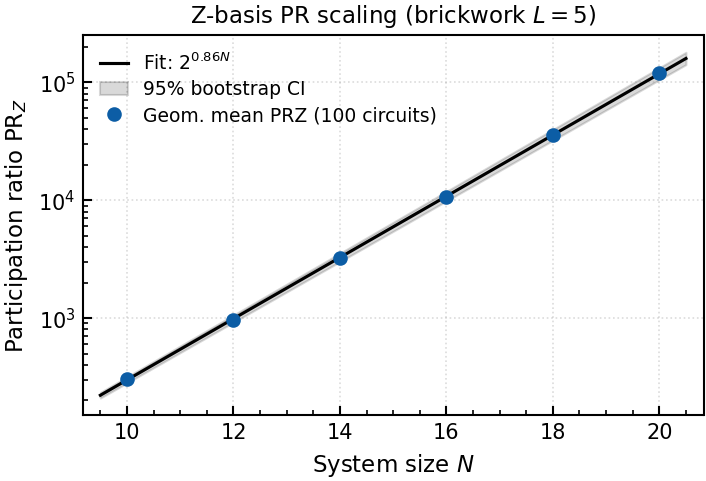

Figure saved.


In [11]:
# ── Figure (Appendix D3) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))

N_plot = np.linspace(N_VALUES[0] - 0.5, N_VALUES[-1] + 0.5, 200)
C_fit  = float(np.exp(logC_fit))
ax.semilogy(N_plot, C_fit * 2**(alpha_fit * N_plot),
            'k-', lw=1.5, label=f'Fit: $2^{{{alpha_fit:.2f}N}}$')

# CI band
ax.fill_between(
    N_plot,
    C_fit * 2**(alpha_lo * N_plot),
    C_fit * 2**(alpha_hi * N_plot),
    alpha=0.15, color='k', label='95% bootstrap CI',
)

ax.semilogy(N_VALUES, prz_gmean, 'o', color='#0C5DA5',
            ms=6, label='Geom. mean PRZ (100 circuits)')

ax.set_xlabel('System size $N$')
ax.set_ylabel('Participation ratio $\\mathrm{PR}_Z$')
ax.set_title('Z-basis PR scaling (brickwork $L=5$)')
ax.legend(fontsize=9)
ax.set_xticks(N_VALUES)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_prz_scaling_fit.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_prz_scaling_fit.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure saved.')